In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from sklearn.metrics import confusion_matrix

In [4]:
# Load the large covalent and non-covalent dataset
df_large_cov = pd.read_csv('../database/combined_covalent_noncovalent_dataset.csv', index_col=False)
df_large_cov['Structure'] = df_large_cov['smiles'].apply(lambda x: Chem.MolFromSmiles(x))
df_large_cov.drop(columns=['label'], inplace=True)
df_large_cov['source'] = 'open_database'

In [8]:
# Covalent Warhead
gen_set_1 = [
'COS(=O)(=O)F',
'CS(=O)(=O)F',
'C=CC(=O)N(C)C',
'C/C=C/C(=O)N(C)C',
'CNC(=O)CCl',
'CNC(=O)C(F)Cl',
'OB(O)c1ccccc1',
'O=Cc1ccccc1B(O)O',
'CC1CO1',
'C=CS(C)(=O)=O',
'C=CS(N)(=O)=O',
'C=C(C#N)C(=O)N(C)C',
'C/C=C(\C#N)C(=O)N(C)C',
'CC#CC(=O)N(C)C',
'N#CN1CCCCC1',
'N#CN1CCCC1'
]
# C4 patent non-covalent cereblon binder
gen_set_2 = [
'O=C1CCC(N2CCc3ccccc32)C(=O)N1',
'O=C1CCC(N2CCc3c(N4CCCCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(N4CCCCC4)ccc32)C(=O)N1',
'O=C1CCC(N2CCc3c(C4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(C4CCNCC4)ccc32)C(=O)N1',
'O=C1CCC(N2CCc3c(N4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(N4CCNCC4)ccc32)C(=O)N1',
'O=C1CCC(N2CCCc3ccccc32)C(=O)N1',
'O=C1CCC(N2CCCc3c(N4CCCCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCCc3c(N4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCCc3c(C4CCNCC4)cccc32)C(=O)N1',
'O=C1CCC(N2CCc3cc(C4CCNCC4)c(F)cc32)C(=O)N1',
"Cc1ccc(OC2CCC(=O)NC2=O)cc1",
"C[C@@H]1CN(c2ccccc2)C(=O)NC1=O",
"O=C1CCC(N2C(=O)c3cccc4cccc2c34)C(=O)N1",
"O=C1CCC(Oc2ccccn2)C(=O)N1",
"CN(c1ccccc1)C1CCC(=O)NC1=O",
"COc1cccc(OC2CCC(=O)NC2=O)c1",
"O=C1CCC(CNc2ccccc2)C(=O)N1",
"COc1ccc(OC2CCC(=O)NC2=O)cc1",
"Cc1cccc(OC2CCC(=O)NC2=O)c1",
"O=C1CCC(n2c(=O)oc3ccccc32)C(=O)N1",
"O=C1NC(=O)C2(Nc3ccccc3)CC1C2",
"O=C1NC(=O)C2(c3ccccc3)CC1C2",
"O=C1CCC(Oc2ccc(C3CCNCC3)cc2)C(=O)N1",
"Cc1ccc(OC2C[C@H](C)C(=O)NC2=O)cc1",
"O=C1CCC(Nc2ccc(C3CCNCC3)cc2)C(=O)N1",
"O=C1CCC(c2ccc(C3CCNCC3)cc2)C(=O)N1",
"O=C1CCN(c2ccc(C3CCNCC3)cc2)C(=O)N1"    
]
# C4 patent covalent cereblon binder
gen_set_3 = [
'O=C1CCC(N2Cc3cc(S(=O)(=O)F)ccc3C2=O)C(=O)N1',
'O=C1CCC(N2Cc3c(cccc3S(=O)(=O)F)C2=O)C(=O)N1',
'O=C1CCC(c2ccc(S(=O)(=O)F)cc2)C(=O)N1',
'Cc1ccc(OC2CCC(=O)NC2=O)cc1S(=O)(=O)F',
'C[C@@H]1CN(c2ccc(S(=O)(=O)F)cc2)C(=O)NC1=O',
'O=C1CCC(Oc2cccc(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(Oc2cccc(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(N2C(=O)c3cc(S(=O)(=O)F)cc4cccc2c34)C(=O)N1',
'O=C1CCC(N2C(=O)c3cc(OS(=O)(=O)F)cc4cccc2c34)C(=O)N1',
'O=C1CCC(Oc2ccc(S(=O)(=O)F)cn2)C(=O)N1',
'Cn1nc(N2CCC(=O)NC2=O)c2cccc(S(=O)(=O)F)c21',
'CN(c1cccc(S(=O)(=O)F)c1)C1CCC(=O)NC1=O',
'CN(c1cccc(OS(=O)(=O)F)c1)C1CCC(=O)NC1=O',
'Cc1ccc(OC2C[C@H](C)C(=O)NC2=O)cc1OS(=O)(=O)F',
'Cc1cc(OC2CCC(=O)NC2=O)cc(OS(=O)(=O)F)c1',
'COc1cc(OC2CCC(=O)NC2=O)cc(OS(=O)(=O)F)c1',
'COc1cc(OC2CCC(=O)NC2=O)cc(S(=O)(=O)F)c1',
'O=C1CCC(CNc2cccc(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCN(c2ccc(OS(=O)(=O)F)cc2)C(=O)N1',
'COc1ccc(OC2CCC(=O)NC2=O)cc1S(=O)(=O)F',
'Cc1cc(OC2CCC(=O)NC2=O)cc(S(=O)(=O)F)c1',
'COc1ccc(OC2CCC(=O)NC2=O)cc1OS(=O)(=O)F',
'O=C1CCC(Oc2ccc(OS(=O)(=O)F)cn2)C(=O)N1',
'O=C1CCC(n2c(=O)oc3c(S(=O)(=O)F)cccc32)C(=O)N1',
'Cn1nc(N2CCC(=O)NC2=O)c2cccc(OS(=O)(=O)F)c21',
'O=C1CCC(Nc2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1NC(=O)C2(Nc3ccc(S(=O)(=O)F)cc3)CC1C2',
'O=C1NC(=O)C2(c3ccc(S(=O)(=O)F)cc3)CC1C2',
'O=C1CCN(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCN(c2ccc(N3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(Oc2ccc(C3CCNCC3)c(S(=O)(=O)F)c2)C(=O)N1',
'O=C1CCC(CNc2cccc(OS(=O)(=O)F)c2)C(=O)N1',
]
#
for smiles_list, cov_label, crbn_label in [(gen_set_1, 1, 0), (gen_set_2, 0, 1), (gen_set_3, 1, 1)]:
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        df_large_cov = pd.concat([df_large_cov, pd.DataFrame({'smiles':[smi], 'Structure':[mol], 'cov_label':[cov_label], 'crbn_chemspace':[crbn_label], 'source': ['patent/paper']})], ignore_index=True)
#
df_large_cov

,smiles,cov_label,crbn_chemspace,Structure,source
0,O=C1CCC(N2Cc3ccc(C(=O)O)cc3C2=O)C(=O)N1,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125be4a5380>,open_database
1,O=C1CCC(N2Cc3cc(C(=O)O)ccc3C2=O)C(=O)N1,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125be4a53f0>,open_database
2,CNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125be4a5460>,open_database
3,CCNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125be4a54d0>,open_database
4,O=C1CCC(N2Cc3cc(C(=O)NC4CC4)ccc3C2=O)C(=O)N1,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125be4a5540>,open_database
...,...,...,...,...,...
8400,O=C1NC(=O)C2(c3ccc(S(=O)(=O)F)cc3)CC1C2,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125b64c4eb0>,patent/paper
8401,O=C1CCN(c2ccc(C3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125b64c4f20>,patent/paper
8402,O=C1CCN(c2ccc(N3CCNCC3)c(OS(=O)(=O)F)c2)C(=O)N1,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125b64c4f90>,patent/paper
8403,O=C1CCC(Oc2ccc(C3CCNCC3)c(S(=O)(=O)F)c2)C(=O)N1,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125b64c5000>,patent/paper


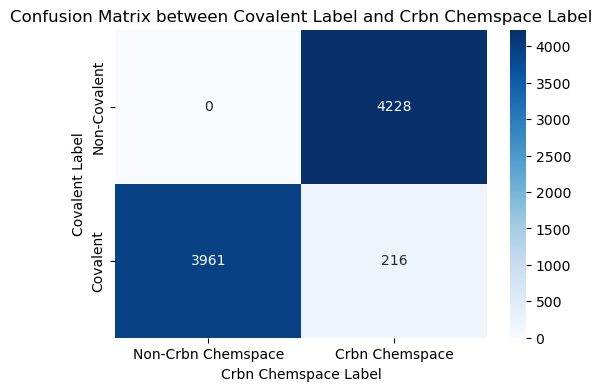

In [11]:
#confusion matrix of the two labels - cov_label and crbn_chemspace
cm = confusion_matrix(df_large_cov['cov_label'], df_large_cov['crbn_chemspace'])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Crbn Chemspace','Crbn Chemspace'], yticklabels=['Non-Covalent','Covalent'])
plt.xlabel('Crbn Chemspace Label')
plt.ylabel('Covalent Label')
plt.title('Confusion Matrix between Covalent Label and Crbn Chemspace Label')
plt.show()

In [12]:
#enrich covalent crbn docking dataset
df = pd.read_csv('../covalent_docking_VS/covalent_docking_unique_2D_precursors_QED_filtered_above_05.csv')
df.rename(columns={'SMILES':'smiles'}, inplace=True)
df.drop(columns=['QED'], inplace=True)
df['cov_label'] = int(1)
df['crbn_chemspace'] = int(1)
df['source'] = 'cheminformatics_docking'
df['Structure'] = df['smiles'].apply(lambda x: Chem.MolFromSmiles(x))
df_large_cov = pd.concat([df_large_cov, df], ignore_index=True)
df_large_cov

,smiles,cov_label,crbn_chemspace,Structure,source
0,O=C1CCC(N2Cc3ccc(C(=O)O)cc3C2=O)C(=O)N1,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125be4a5380>,open_database
1,O=C1CCC(N2Cc3cc(C(=O)O)ccc3C2=O)C(=O)N1,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125be4a53f0>,open_database
2,CNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125be4a5460>,open_database
3,CCNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125be4a54d0>,open_database
4,O=C1CCC(N2Cc3cc(C(=O)NC4CC4)ccc3C2=O)C(=O)N1,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125be4a5540>,open_database
...,...,...,...,...,...
10695,O=C1CCC(c2cccc(NC(=O)C3Cc4cc(S(=O)(=O)F)ccc4N3...,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125ad0089e0>,cheminformatics_docking
10696,O=C1CCC(c2cccc(NC(=O)C3Cc4cccc(S(=O)(=O)F)c4N3...,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125ad008a50>,cheminformatics_docking
10697,O=C1CCC(c2ccc(Nc3ccn4ncc(S(=O)(=O)F)c4n3)cc2)C...,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125ad008ac0>,cheminformatics_docking
10698,O=C1CCC(N2C(=O)c3ncc(OS(=O)(=O)F)nc3C2=O)C(=O)N1,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125ad008b30>,cheminformatics_docking


In [13]:
#remove stereochemistry for further ML simplification
def remove_stereo_and_smiles(x):
    Chem.RemoveStereochemistry(x)
    return Chem.MolToSmiles(x)
#
df_large_cov['smiles'] = df_large_cov['Structure'].apply(remove_stereo_and_smiles)
df_large_cov.drop_duplicates(subset=['smiles'], inplace=True, keep='first')
df_large_cov['Structure'] = df_large_cov['smiles'].apply(lambda x: Chem.MolFromSmiles(x))
df_large_cov

,smiles,cov_label,crbn_chemspace,Structure,source
0,O=C1CCC(N2Cc3ccc(C(=O)O)cc3C2=O)C(=O)N1,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125aced2340>,open_database
1,O=C1CCC(N2Cc3cc(C(=O)O)ccc3C2=O)C(=O)N1,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125aced2030>,open_database
2,CNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125ace7bca0>,open_database
3,CCNC(=O)c1ccc2c(c1)CN(C1CCC(=O)NC1=O)C2=O,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125ace7bc30>,open_database
4,O=C1CCC(N2Cc3cc(C(=O)NC4CC4)ccc3C2=O)C(=O)N1,0.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125ace7bbc0>,open_database
...,...,...,...,...,...
10695,O=C1CCC(c2cccc(NC(=O)C3Cc4cc(S(=O)(=O)F)ccc4N3...,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125ace33bc0>,cheminformatics_docking
10696,O=C1CCC(c2cccc(NC(=O)C3Cc4cccc(S(=O)(=O)F)c4N3...,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125ace33c30>,cheminformatics_docking
10697,O=C1CCC(c2ccc(Nc3ccn4ncc(S(=O)(=O)F)c4n3)cc2)C...,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125ace33ca0>,cheminformatics_docking
10698,O=C1CCC(N2C(=O)c3ncc(OS(=O)(=O)F)nc3C2=O)C(=O)N1,1.0,1,<rdkit.Chem.rdchem.Mol object at 0x7125ace33d10>,cheminformatics_docking


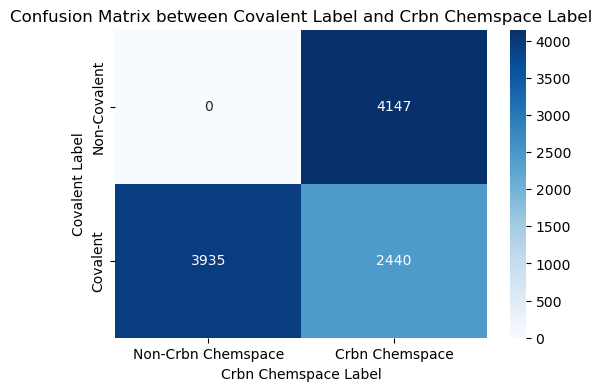

In [14]:
#check chemspace after enrichment
cm = confusion_matrix(df_large_cov['cov_label'], df_large_cov['crbn_chemspace'])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Crbn Chemspace','Crbn Chemspace'], yticklabels=['Non-Covalent','Covalent'])
plt.xlabel('Crbn Chemspace Label')
plt.ylabel('Covalent Label')
plt.title('Confusion Matrix between Covalent Label and Crbn Chemspace Label')
plt.show()

In [15]:
df_large_cov['cov_crbn_label'] = df_large_cov.apply(lambda row: 1 if (row['cov_label'] == 1 and row['crbn_chemspace'] == 1) else 0, axis=1)
df_large_cov[['source', 'cov_crbn_label']].value_counts()

source                   cov_crbn_label
open_database            0                 8037
cheminformatics_docking  1                 2257
open_database            1                  150
patent/paper             0                   45
                         1                   33
Name: count, dtype: int64

In [21]:
df_large_cov.drop(columns=['Structure'], inplace=True)
df_large_cov.to_csv('final_dataset_for_classification.csv', index=False)